# A Relation Is a Rotation — On a Real Graph
### Companion notebook to the *Knowledge Graphs as Geometry* follow-up post

Chapter 4 made a relation a **rotation**: turn the head, score by the distance left to the tail. There it was six people in a family graph. Here the same geometry runs a bank's compliance memory in [**knowlytix**](https://knowlytix.ai/) — 40 policy entities on a sphere in R³², each relation a rotor in SO(32), a fact's plausibility the geodesic distance after the turn.

Everything below is a call to the knowlytix store. We reproduce, on a real graph, the four things Chapter 4 proved on the toy one:

1. the relation is a genuine rotation (isometry, clean inverse),
2. plausibility is the distance after that rotation,
3. ranking falls out of one turn plus a table of distances,
4. composition does **not** commute — order matters, past the RotatE ceiling.

## Setup

knowlytix installs from **PyPI** and is free to use. Request a free license key and follow the install instructions at [knowlytix.ai/signup](https://knowlytix.ai/signup/) (overview at [knowlytix.ai](https://knowlytix.ai/)), then run the install command they give you (uncomment below) on a fresh environment such as Colab.

In [1]:
# Install per the instructions at https://knowlytix.ai/signup/ (free license), e.g.:
# !pip install knowlytix
import torch
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## The source: policy as a document

The store is built from a small excerpt of a bank policy — a fee schedule, the workflow authorizations, the regulatory flags and their escalation targets, and the reversal limits. We write it to disk so the notebook is self-contained.

In [2]:
from pathlib import Path
POLICY = r'''# Bank Policy (Chapter 2 excerpt)

A small excerpt of the bank's policy, used to build a knowledge graph and a
geometric memory store for the Chapter 2 primer.

## Fee Schedule

| product | fee_amount | type |
|---------|-----------:|------|
| overdraft | 35.00 | per_occurrence |
| nsf_check | 35.00 | per_event |
| late_payment | 25.00 | per_event |
| wire_domestic | 30.00 | per_transaction |
| wire_international | 45.00 | per_transaction |
| stop_payment | 30.00 | per_request |

## Workflow Authorizations

| state | enables | role |
|-------|---------|------|
| start | classify | router |
| classify | extract | router |
| extract | search_policy | router |
| search_policy | flag_regulatory | router |
| flag_regulatory | draft_response | drafter |
| flag_regulatory | escalate | compliance |
| draft_response | escalate | compliance |

## Regulatory Flags

| flag | applies_when | escalates_to | threshold |
|------|--------------|--------------|----------:|
| UDAAP | unfair_or_abusive_fee | compliance | 500.00 |
| Reg_X | mortgage_servicing_issue | compliance | 0.00 |
| Reg_E | unauthorized_electronic_transfer | dispute_unit | 50.00 |
| Reg_Z | credit_card_billing_error | dispute_unit | 0.00 |

## Reversal Authority

| role | max_reversal |
|------|-------------:|
| representative | 35.00 |
| supervisor | 100.00 |
| manager | 500.00 |

## Schema Declarations

- has_fee_amount is_functional True
- has_max_reversal is_functional True
- has_threshold is_functional True
'''
DOC = Path('ch2_bank_policy.md')
DOC.write_text(POLICY)
print(DOC.read_text()[:480])

# Bank Policy (Chapter 2 excerpt)

A small excerpt of the bank's policy, used to build a knowledge graph and a
geometric memory store for the Chapter 2 primer.

## Fee Schedule

| product | fee_amount | type |
|---------|-----------:|------|
| overdraft | 35.00 | per_occurrence |
| nsf_check | 35.00 | per_event |
| late_payment | 25.00 | per_event |
| wire_domestic | 30.00 | per_transaction |
| wire_international | 45.00 | per_transaction |
| stop_payment | 30.00 | per_reques


## From document to a geometric store (knowlytix GEODE)

The build parses the policy tables into typed triples and trains the geometry: every entity a point on the sphere, every relation a Cayley rotor `Rᵣ = (I − Wᵣ)(I + Wᵣ)⁻¹` in SO(32). It is built once and loaded thereafter.

*Reproducibility:* the build trains a fresh model, so the exact decimals below are from your run; the post quotes one cached store. The structure — committed facts near zero, wrong ones far, non-commuting rotors — reproduces every time.

In [3]:
from knowlytix.knowledge.geode import build_rag_store, make_default_trainer
from knowlytix.knowledge.query import DocGMSConfig, GMSExpertStore
from knowlytix.core.config import GeometryConfig, TrainConfig, CapLossConfig

STORE = 'gms_ch2_store'
cfg = DocGMSConfig(store_path=STORE, ingest_mode='regex', loss_mode='cap',
                   geometry=GeometryConfig(d_v=64, d_u=64, m=32, d=32),
                   cap=CapLossConfig(n_boundary=4),
                   train=TrainConfig(epochs=400, batch_size=64, neg_samples=8,
                                     lr=5e-3, lr_riemannian=2e-3))

if Path(STORE).exists():
    store = GMSExpertStore(cfg, device=device); store.load()
else:
    res = build_rag_store(str(DOC), cfg, device=device,
                          geode_trainer=make_default_trainer(device, epochs=120),
                          max_iters=3)
    store = res.store

print('entities:', len(store.adapter.entity_to_idx),
      ' relations:', len(store.adapter.relation_to_idx),
      ' triples:', len(store.query_triples()))

knowlytix-core v0.2.0 licensed to customer=KnowlytixAgentBuilder tier=enterprise expires=2027-06-04


  GMS entities:  48
  GMS relations: 10
  GMS triples:   63


/home/asudjianto/cluster/spark-venv/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


  Training data prepared:
    Triples:              63
    Agreement pairs:      18
    Contradiction pairs:  33
    Relation triangles:   2

Training GMS (cap): 48 entities, 10 relations, 63 triples
  Config: d_v=64, m=32, epochs=120, batch=64, neg=16+8 boundary
  Cap:    rho_max=1.5708, alpha=4.0, margin=0.3, use_diag=True
  Weights: pos=5.0, neg=2.0, shrink=0.05, barrier=0.01, lambda_tension=0.5
  Device: cuda
  Epoch    1/120  Loss: 27.8173  (L_pos=4.5543, L_neg=1.5165, rho_mean=0.392, rho_max=0.392, L_te=0.8102, L_path=1.5475)
  Epoch   20/120  Loss: 4.2492  (L_pos=0.4804, L_neg=0.6176, rho_mean=0.419, rho_max=0.420, L_te=0.0995, L_path=0.3942)
  Epoch   40/120  Loss: 3.1092  (L_pos=0.2343, L_neg=0.7396, rho_mean=0.430, rho_max=0.440, L_te=0.0831, L_path=0.2224)
  Epoch   60/120  Loss: 2.6017  (L_pos=0.2427, L_neg=0.5191, rho_mean=0.432, rho_max=0.453, L_te=0.0680, L_path=0.1621)
  Epoch   80/120  Loss: 2.3570  (L_pos=0.2192, L_neg=0.4725, rho_mean=0.436, rho_max=0.468, L_te=0.034

## A fact is a triple `(head, relation, tail)`

The policy tables became typed triples under named relations. A triple is a geodesic arc on the sphere: the relation's rotor turns the head to the tail.

In [4]:
from collections import defaultdict
by_rel = defaultdict(list)
for h, r, t in sorted(store.query_triples()):
    by_rel[r].append((h, t))
for r in ('has_fee_amount', 'has_enables', 'has_escalates_to'):
    print(r)
    for h, t in by_rel[r]:
        print(f'    {h} -> {t}')

has_fee_amount
    late_payment -> 25.0
    nsf_check -> 35.0
    overdraft -> 35.0
    stop_payment -> 30.0
    wire_domestic -> 30.0
    wire_international -> 45.0
has_enables
    classify -> extract
    draft_response -> escalate
    extract -> search_policy
    flag_regulatory -> draft_response
    flag_regulatory -> escalate
    search_policy -> flag_regulatory
    start -> classify
has_escalates_to
    reg_e -> dispute_unit
    reg_x -> compliance
    reg_z -> dispute_unit
    udaap -> compliance


## The graph on the sphere

knowlytix ships its own visualizer. Every entity is a point; every relation a color; every triple a geodesic arc in the relation's color — the rotor at work.

In [5]:
from knowlytix.knowledge.viz import from_store_dir, sphere_figure
kg = from_store_dir(STORE, source='v')
fig = sphere_figure(kg, title='Bank-policy knowledge graph — knowlytix GMS')
fig

## Plausibility is the distance after the turn

`score_triple` turns the head with the relation's rotor and returns the geodesic distance to the proposed tail — **lower is more plausible**. The committed fee sits near zero; a wrong (but plausible) one lands most of a right angle away. The same primitive scores a fact and a workflow step, because both are triples.

In [6]:
print('fact check  (has_fee_amount):')
for tail, label in [('35.0', 'committed'), ('45.0', 'wrong: wire fee')]:
    s = store.score_triple('overdraft', 'has_fee_amount', tail)
    print(f'  (overdraft, has_fee_amount, {tail}) -> {s:.3f}  {label}')
print('transition check (has_enables):')
for tail, label in [('extract', 'legal next step'), ('draft_response', 'skips ahead')]:
    s = store.score_triple('classify', 'has_enables', tail)
    print(f'  (classify, has_enables, {tail}) -> {s:.3f}  {label}')

fact check  (has_fee_amount):
  (overdraft, has_fee_amount, 35.0) -> 0.052  committed
  (overdraft, has_fee_amount, 45.0) -> 1.527  wrong: wire fee
transition check (has_enables):
  (classify, has_enables, extract) -> 0.006  legal next step
  (classify, has_enables, draft_response) -> 1.576  skips ahead


## Ranking: turn once, sort by distance

Because a rotor preserves length, ranking the candidate tails is one rotation of the head followed by a distance to a fixed table of points. `link_predict` returns the committed value first.

In [7]:
for tail, dist in store.link_predict('overdraft', 'has_fee_amount', top_k=4):
    print(f'  {tail:>5}  {dist:.3f}')

   35.0  0.466
   25.0  1.311
   45.0  1.450
   30.0  1.493


## The relation really is a rotation

A rotation preserves length and has a clean inverse. Pull the trained rotor for each relation and check both. Orthogonality residual `‖RRᵀ − I‖` is machine-zero and every determinant is +1 (a proper rotation: no reflection, no scale, no shear). The inverse is the transpose — Chapter 4's reverse turn, `Rᵣ⁻¹ = Rᵣᵀ`.

In [8]:
gkg = store.model
r2i = store.adapter.relation_to_idx
I = torch.eye(gkg.cfg.m, device=store.device)
print('relation            ||RRᵀ−I||     det R')
for rel, i in sorted(r2i.items()):
    R = gkg.get_rotor(i).get_rotor()
    orth = (R @ R.T - I).norm().item()
    det = torch.linalg.det(R).item()
    print(f'  {rel:20s} {orth:.2e}   {det:+.4f}')

v = torch.randn(gkg.cfg.m, device=store.device); v = v / v.norm()
R = gkg.get_rotor(r2i['has_escalates_to']).get_rotor()
print('inverse = transpose  ||RᵀRv − v|| =', f'{(R.T @ (R @ v) - v).norm().item():.2e}')

relation            ||RRᵀ−I||     det R
  has_applies_when     9.74e-06   +1.0000
  has_enables          9.76e-06   +1.0000
  has_escalates_to     9.59e-06   +1.0000
  has_fee_amount       9.29e-06   +1.0000
  has_max_reversal     9.37e-06   +1.0000
  has_role             9.48e-06   +1.0000
  has_threshold        9.92e-06   +1.0000
  has_type             9.85e-06   +1.0000
inverse = transpose  ||RᵀRv − v|| = 1.70e-06


## Order matters — past the ceiling of Chapter 4

RotatE composes relations by adding angles, and angles commute: it forces every pair of relations to be order-blind. knowlytix rotors live in SO(32), which is noncommutative — the QuatE lesson, generalized. knowlytix composes a multi-hop path by composing the rotors along it (`compose_rotors`); doing two relations in the two orders gives two different rotations. For RotatE this gap would be exactly 0.

In [9]:
from knowlytix.core.geometry.cayley import compose_rotors
import itertools
rels = ['has_applies_when', 'has_escalates_to', 'has_enables', 'has_fee_amount']
for a, b in itertools.combinations(rels, 2):
    Ra = gkg.get_rotor(r2i[a]).get_rotor()
    Rb = gkg.get_rotor(r2i[b]).get_rotor()
    gap = (compose_rotors([Ra, Rb]) - compose_rotors([Rb, Ra])).norm().item()
    print(f'  ||R[{a}] R[{b}] - R[{b}] R[{a}]|| = {gap:.3f}')

# knowlytix exposes check_holonomy: how far a composed path is from a direct claim
h = store.check_holonomy(['has_applies_when', 'has_escalates_to'], 'has_escalates_to')
print('check_holonomy(applies_when o escalates_to  vs  escalates_to) =', round(h, 3))

  ||R[has_applies_when] R[has_escalates_to] - R[has_escalates_to] R[has_applies_when]|| = 4.549
  ||R[has_applies_when] R[has_enables] - R[has_enables] R[has_applies_when]|| = 3.138
  ||R[has_applies_when] R[has_fee_amount] - R[has_fee_amount] R[has_applies_when]|| = 3.906
  ||R[has_escalates_to] R[has_enables] - R[has_enables] R[has_escalates_to]|| = 3.480
  ||R[has_escalates_to] R[has_fee_amount] - R[has_fee_amount] R[has_escalates_to]|| = 4.267
  ||R[has_enables] R[has_fee_amount] - R[has_fee_amount] R[has_enables]|| = 3.538
check_holonomy(applies_when o escalates_to  vs  escalates_to) = 3.279


The same gaps as a figure: brown bars are the knowlytix SO(32) rotors, the flat blue line at zero is RotatE, where every pair of relations commutes by construction.

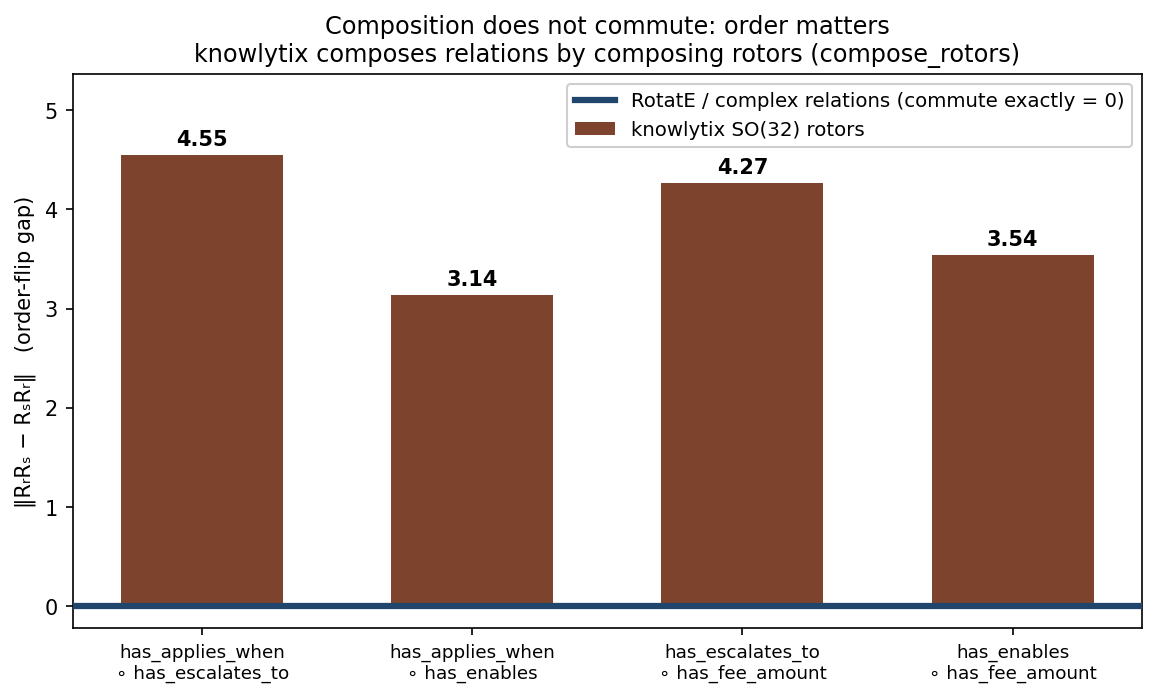

In [10]:
# The same order-flip gaps as a figure (matches Figure C in the post).
import numpy as np
import matplotlib.pyplot as plt

pairs = [('has_applies_when', 'has_escalates_to'),
         ('has_applies_when', 'has_enables'),
         ('has_escalates_to', 'has_fee_amount'),
         ('has_enables', 'has_fee_amount')]
vals = []
for a, b in pairs:
    Ra = gkg.get_rotor(r2i[a]).get_rotor()
    Rb = gkg.get_rotor(r2i[b]).get_rotor()
    vals.append((compose_rotors([Ra, Rb]) - compose_rotors([Rb, Ra])).norm().item())

BROWN, BLUE = '#7d432d', '#20466e'
fig, ax = plt.subplots(figsize=(9.2, 4.8))
x = np.arange(len(pairs))
ax.bar(x, vals, color=BROWN, width=0.6, zorder=2, label='knowlytix SO(32) rotors')
# RotatE's order-flip gap is exactly 0; float the zero line just above the
# bottom frame so it reads as a flat blue line rather than the x-axis.
ax.axhline(0, color=BLUE, linewidth=3.0, zorder=4,
           label='RotatE / complex relations (commute exactly = 0)')
ax.set_xticks(x)
ax.set_xticklabels([f'{a}\n∘ {b}' for a, b in pairs], fontsize=8.8)
ax.set_ylabel('‖RᵣRₛ − RₛRᵣ‖   (order-flip gap)')
ax.set_title('Composition does not commute: order matters\n'
             'knowlytix composes relations by composing rotors (compose_rotors)',
             fontsize=11.5)
for xi, v in zip(x, vals):
    ax.text(xi, v + 0.06, f'{v:.2f}', ha='center', va='bottom',
            fontsize=10, weight='bold')
top = max(vals) * 1.18
ax.set_ylim(-0.22, top)
ax.set_yticks(np.arange(0, int(top) + 1))
ax.legend(fontsize=9.5, loc='upper right', framealpha=0.95)
plt.show()


## How tolerant is each relation? The spherical cap

A functional relation (an overdraft has one fee) should accept one tail; a one-to-many relation (a state can enable several) should be looser. knowlytix gives each relation a learned admissible radius — a cap around the turned head. A tail inside the cap fits; outside, it does not.

In [11]:
radii = store.cap_radii_all()
for rel, rho in sorted(radii.items(), key=lambda kv: kv[1]):
    print(f'  {rel:20s} rho = {rho:.3f} rad')

  has_applies_when     rho = 0.561 rad
  has_max_reversal     rho = 0.601 rad
  has_fee_amount       rho = 0.611 rad
  has_enables          rho = 0.612 rad
  has_type             rho = 0.619 rad
  has_threshold        rho = 0.623 rad
  has_escalates_to     rho = 0.633 rad
  has_role             rho = 0.687 rad


## Entity resolution and the escalation chain

`fuzzy_match_entity` resolves a surface phrase to a canonical node — what an agent needs to turn free text into a graph query. The regulatory escalation the agent performs is a two-hop walk across two different relations: evidence → flag → desk.

In [12]:
for q in ['overdraft fee', 'compliance team', 'escalate']:
    print(f'  {q!r} -> {store.fuzzy_match_entity(q)!r}')

def heads_with(relation, tail):
    return [h for h, r, t in store.query_triples(relation=relation, tail=tail)]
def tails_of(head, relation):
    return [t for h, r, t in store.query_triples(head=head, relation=relation)]

evidence = 'unfair_or_abusive_fee'
for flag in heads_with('has_applies_when', evidence):        # hop 1: evidence -> flag
    target = tails_of(flag, 'has_escalates_to')              # hop 2: flag -> desk
    print(f'{evidence} -> {flag} -> escalate to {target}')

  'overdraft fee' -> 'overdraft'
  'compliance team' -> 'compliance'
  'escalate' -> 'escalate'
unfair_or_abusive_fee -> udaap -> escalate to ['compliance']


## Summary

A relation is a rotation, and that is the memory an AI agent can be held to. On a real bank policy, knowlytix places entities on a sphere, makes each relation a rotor, and reads a fact's plausibility as the distance after the turn: the committed fee at the pole the relation points to, the wrong one a right angle away, a skip-ahead workflow step nowhere near what the policy allows. The rotors are genuine rotations (isometry, transpose inverse), and — unlike RotatE — they do not commute, so order-dependent reasoning survives. The operator did not change between six people and forty; only what was at stake did.

knowlytix installs from PyPI and is free to use — request a license key and the install command at [knowlytix.ai/signup](https://knowlytix.ai/signup/) (overview at [knowlytix.ai](https://knowlytix.ai/)).